In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'

df = pd.read_csv(url, header=None)

# print(df.describe(include="all"))

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       205 non-null    int64  
 1   1       205 non-null    str    
 2   2       205 non-null    str    
 3   3       205 non-null    str    
 4   4       205 non-null    str    
 5   5       205 non-null    str    
 6   6       205 non-null    str    
 7   7       205 non-null    str    
 8   8       205 non-null    str    
 9   9       205 non-null    float64
 10  10      205 non-null    float64
 11  11      205 non-null    float64
 12  12      205 non-null    float64
 13  13      205 non-null    int64  
 14  14      205 non-null    str    
 15  15      205 non-null    str    
 16  16      205 non-null    int64  
 17  17      205 non-null    str    
 18  18      205 non-null    str    
 19  19      205 non-null    str    
 20  20      205 non-null    float64
 21  21      205 non-null    str    
 22  22      205 n

In [2]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [3]:
df.head(10)
# df.columns = [...]  # Assign column names if needed
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]
df.columns = headers
df.head(10)
print(df.dtypes)

symboling              int64
normalized-losses        str
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object


In [4]:
df['wheel-base'] = df['wheel-base']+1
# alter the dataframe as needed row-wise
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,89.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,89.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,95.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,100.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,100.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,100.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,106.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,106.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,106.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,100.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


In [5]:
df1 = df.replace('?', np.nan)
# df.dropna()
df1.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,89.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,89.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,95.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,100.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,100.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,NaN,audi,gas,std,two,sedan,fwd,front,100.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,106.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,NaN,audi,gas,std,four,wagon,fwd,front,106.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,106.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,NaN,audi,gas,turbo,two,hatchback,4wd,front,100.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,NaN


In [6]:
df1.dropna(inplace=True, axis=0)
df1.head(10)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
3,2,164,audi,gas,std,four,sedan,fwd,front,100.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,100.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
6,1,158,audi,gas,std,four,sedan,fwd,front,106.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
8,1,158,audi,gas,turbo,four,sedan,fwd,front,106.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
10,2,192,bmw,gas,std,two,sedan,rwd,front,102.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16430
11,0,192,bmw,gas,std,four,sedan,rwd,front,102.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16925
12,0,188,bmw,gas,std,two,sedan,rwd,front,102.2,...,164,mpfi,3.31,3.19,9.0,121,4250,21,28,20970
13,0,188,bmw,gas,std,four,sedan,rwd,front,102.2,...,164,mpfi,3.31,3.19,9.0,121,4250,21,28,21105
18,2,121,chevrolet,gas,std,two,hatchback,fwd,front,89.4,...,61,2bbl,2.91,3.03,9.5,48,5100,47,53,5151
19,1,98,chevrolet,gas,std,two,hatchback,fwd,front,95.5,...,90,2bbl,3.03,3.11,9.6,70,5400,38,43,6295


In [7]:
df1["price"] = df1["price"].astype("int")
# Change the string type to the float type
df1.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
3,2,164,audi,gas,std,four,sedan,fwd,front,100.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,100.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
6,1,158,audi,gas,std,four,sedan,fwd,front,106.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
8,1,158,audi,gas,turbo,four,sedan,fwd,front,106.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
10,2,192,bmw,gas,std,two,sedan,rwd,front,102.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16430
11,0,192,bmw,gas,std,four,sedan,rwd,front,102.2,...,108,mpfi,3.50,2.80,8.8,101,5800,23,29,16925
12,0,188,bmw,gas,std,two,sedan,rwd,front,102.2,...,164,mpfi,3.31,3.19,9.0,121,4250,21,28,20970
13,0,188,bmw,gas,std,four,sedan,rwd,front,102.2,...,164,mpfi,3.31,3.19,9.0,121,4250,21,28,21105
18,2,121,chevrolet,gas,std,two,hatchback,fwd,front,89.4,...,61,2bbl,2.91,3.03,9.5,48,5100,47,53,5151
19,1,98,chevrolet,gas,std,two,hatchback,fwd,front,95.5,...,90,2bbl,3.03,3.11,9.6,70,5400,38,43,6295


In [8]:
# Simple Feature Scaling Normalization
df1['normalized-losses'] = df1['normalized-losses'].astype('int')
df1['normalized-losses'] = df1['normalized-losses']/df1['normalized-losses'].max()
df1['normalized-losses'].head(10)

3     0.640625
4     0.640625
6     0.617188
8     0.617188
10    0.750000
11    0.750000
12    0.734375
13    0.734375
18    0.472656
19    0.382812
Name: normalized-losses, dtype: float64

In [9]:
# Min-Max Normalization
df1['length'] = df1['length'].astype('int')
df1['length'] = (df1['length'] - df1['length'].min()) / (df1['length'].max() - df1['length'].min())
print(df1['length'].head(10))

3     0.573770
4     0.573770
6     0.836066
8     0.836066
10    0.573770
11    0.573770
12    0.573770
13    0.573770
18    0.000000
19    0.229508
Name: length, dtype: float64


In [10]:
# Z-score Normalization
df1['width'] = df1['width'].astype('int')
df1['width'] = (df1['width'] - df1['width'].mean()) / df1['width'].std()
print(df1['width'].head(10))

3     0.449131
4     0.449131
6     2.981468
8     2.981468
10   -0.563803
11   -0.563803
12   -0.563803
13   -0.563803
18   -2.589673
19   -1.070271
Name: width, dtype: float64


3     13950
4     17450
6     17710
8     23875
10    16430
11    16925
12    20970
13    21105
18     5151
19     6295
Name: price, dtype: int64


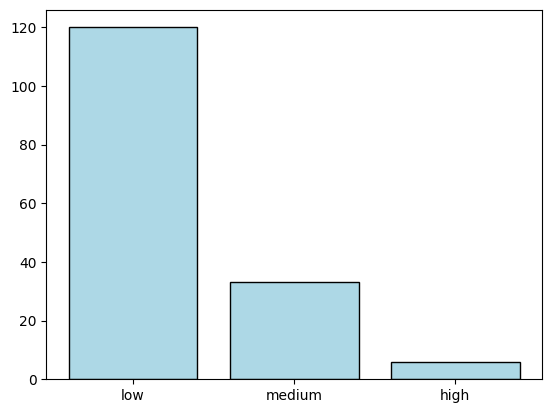

In [11]:

# Binning
df1["price"].astype("float")
print(df1["price"].head(10))
bins = np.linspace(min(df1["price"]),max(df1["price"]),4)
group_names = ['low', 'medium', 'high']
df["price_binned"] = pd.cut(df1["price"], bins,labels= group_names, include_lowest= True)

# 1. Count the occurrences of each bin
bin_counts = df["price_binned"].value_counts()

# 2. Create the bar plot
plt.bar(bin_counts.index, bin_counts.values, color='lightblue', edgecolor='black')

# # 3. Add labels and title
# plt.xlabel("Price Categories")
# plt.ylabel("Number of Items")
# plt.title("Distribution of Binned Prices")

plt.show()


In [12]:
var1 = pd.get_dummies(df1["aspiration"])
df1 = pd.concat([df1, var1], axis=1)

In [13]:
df1_test = df1[["drive-wheels", "body-style", "price"]]
df_group = df1_test.groupby(['drive-wheels', 'body-style'], as_index=False).mean()
print(df_group)

   drive-wheels   body-style         price
0           4wd    hatchback   7603.000000
1           4wd        sedan  12647.333333
2           4wd        wagon   9095.750000
3           fwd      hardtop   8249.000000
4           fwd    hatchback   7989.800000
5           fwd        sedan   9558.120000
6           fwd        wagon   8829.222222
7           rwd  convertible  26362.500000
8           rwd      hardtop  14365.750000
9           rwd    hatchback  14918.500000
10          rwd        sedan  18318.576923
11          rwd        wagon  19282.000000


In [14]:
drf_piviot = df_group.pivot(index='drive-wheels', columns='body-style')
print(drf_piviot)

                   price                                                
body-style   convertible   hardtop hatchback         sedan         wagon
drive-wheels                                                            
4wd                  NaN       NaN    7603.0  12647.333333   9095.750000
fwd                  NaN   8249.00    7989.8   9558.120000   8829.222222
rwd              26362.5  14365.75   14918.5  18318.576923  19282.000000


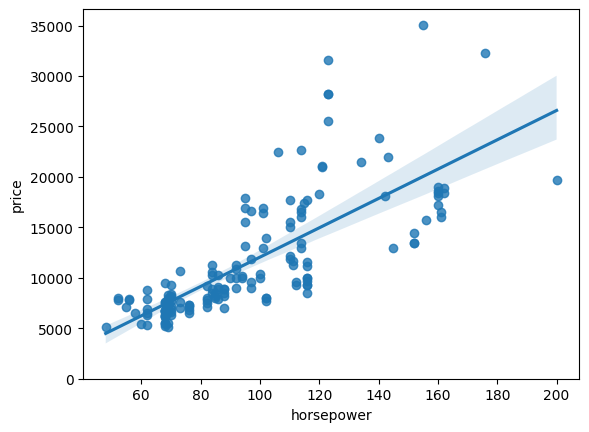

In [15]:
df1["horsepower"] = df1["horsepower"].astype("float")
sns.regplot(x="horsepower", y="price", data=df1)
plt.ylim(0,)
plt.show()

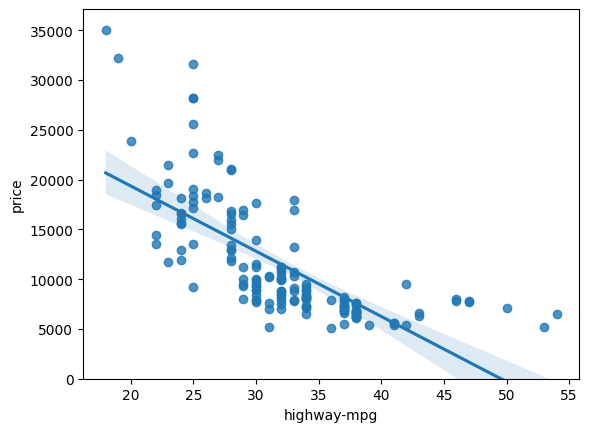

In [16]:
sns.regplot(x="highway-mpg", y="price", data=df1)
plt.ylim(0,)
plt.show()

In [17]:
df1[["engine-size", "price", "horsepower", "bore"]].corr()

,engine-size,price,horsepower,bore
engine-size,1.000000,0.841496,0.812073,0.595737
price,0.841496,1.000000,0.759874,0.533890
horsepower,0.812073,0.759874,1.000000,0.560239
bore,0.595737,0.533890,0.560239,1.000000


<Axes: xlabel='stroke', ylabel='price'>

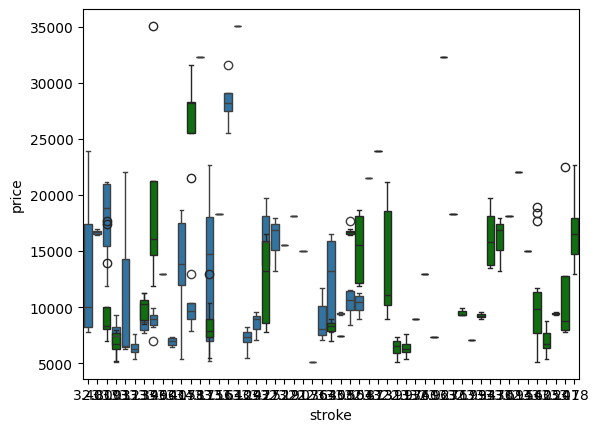

In [18]:
sns.boxplot(x="stroke", y="price", data=df1)
sns.boxplot(x="bore", y="price", data=df1, color="green")

In [19]:
avg_price_by_style = df1.groupby('body-style')['price'].mean()

print(avg_price_by_style)

body-style
convertible    26362.500000
hardtop        13142.400000
hatchback       9220.160714
sedan          12558.620253
wagon          11351.411765
Name: price, dtype: float64


In [20]:
lm = LinearRegression()
x = df1[["highway-mpg"]]
y = df1[["price"]]
lm.fit(x,y)
yhat = lm.predict(x)
# xhat = lm.predict(y)
print(yhat[0:5])

print(f"Slope (Coefficient): {lm.coef_}")
print(f"Intercept: {lm.intercept_}")

[[12809.86873425]
 [18052.11958005]
 [16086.27551287]
 [19362.6822915 ]
 [13465.15008997]]
Slope (Coefficient): [[-655.28135573]]
Intercept: [32468.309406]


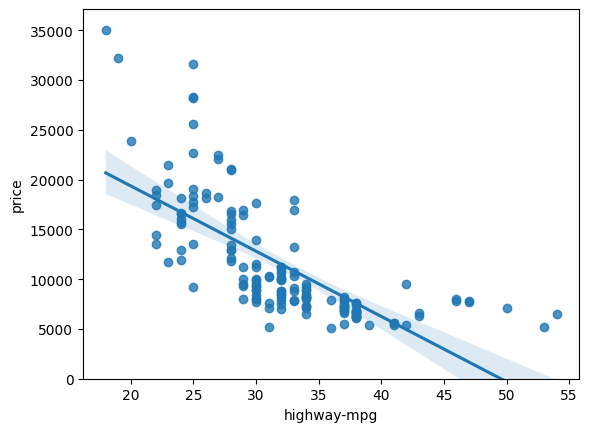

In [21]:
sns.regplot(x="highway-mpg", y="price", data=df1)
plt.ylim(0,)
plt.show()

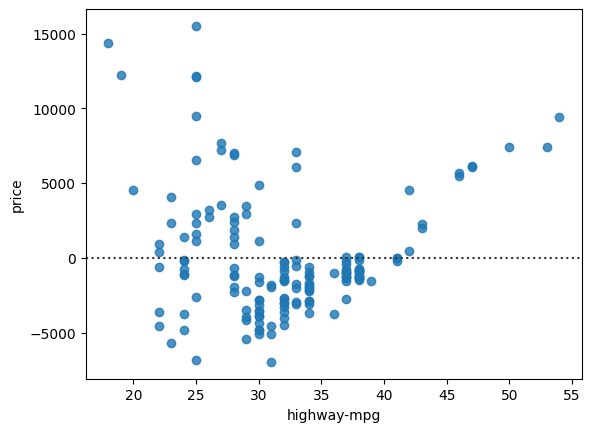

In [22]:
sns.residplot(x="highway-mpg", y="price", data=df1)
plt.show()

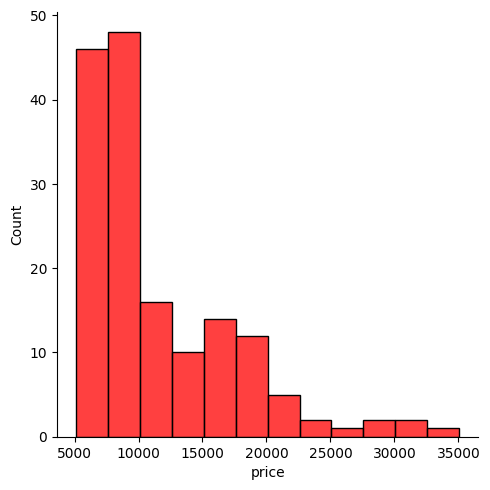

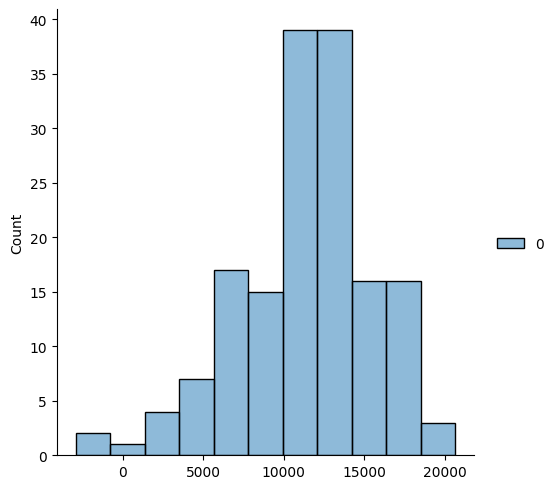

In [23]:
ax1 = sns.displot(df1['price'], color="r", label="Actual Value")
sns.displot(yhat, color="b", label="Fitted Value")
plt.show()

         3         2
-0.5756 x + 95.52 x - 5071 x + 9.325e+04


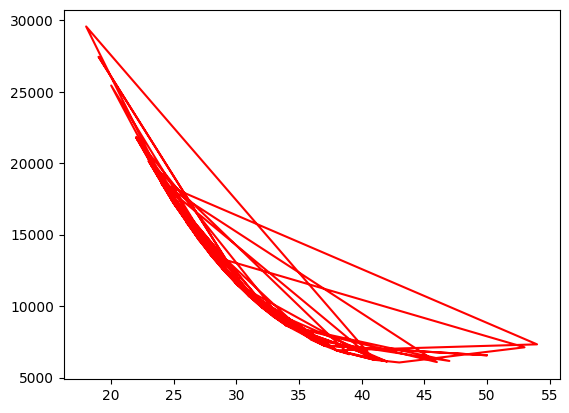

In [24]:
f = np.polyfit(df1["highway-mpg"], df1["price"], 3)
p = np.poly1d(f)
print(p)
# plt.scatter(df1["highway-mpg"], df1["price"])
plt.plot(df1["highway-mpg"], p(df1["highway-mpg"]), color="red")
plt.show()

In [25]:
from sklearn.preprocessing import PolynomialFeatures

pr = PolynomialFeatures(degree=2, include_bias=False)
pr.fit_transform(df1[["highway-mpg"]])
print(pr)


PolynomialFeatures(include_bias=False)


3     102.0
4     115.0
6     110.0
8     140.0
10    101.0
11    101.0
12    121.0
13    121.0
18     48.0
19     70.0
Name: horsepower, dtype: float64


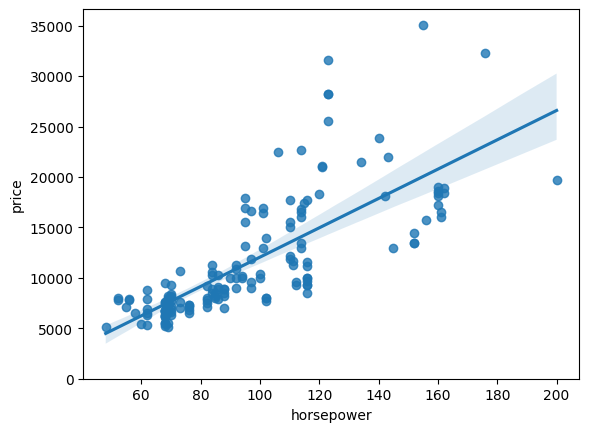

[[ 0.20127869]
 [ 0.62581242]
 [ 0.46253021]
 [ 1.44222343]
 [ 0.16862225]
 [ 0.16862225]
 [ 0.82175106]
 [ 0.82175106]
 [-1.5621691 ]
 [-0.84372741]]


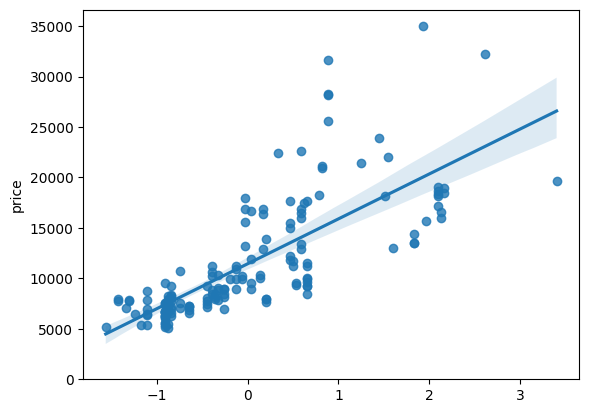

In [26]:
from sklearn.preprocessing import StandardScaler

SCALE = StandardScaler()
print(df1["horsepower"].head(10))
sns.regplot(x="horsepower", y="price", data=df1)
plt.ylim(0,)
plt.show()
X_scaled = SCALE.fit_transform(df1[["horsepower"]])
print(X_scaled[0:10])
sns.regplot(x=X_scaled, y="price", data=df1)
plt.ylim(0,)
plt.show()


<h1>Pipeline generation</h1>

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

inp = Pipeline([('scale', StandardScaler()), ('polynomial', PolynomialFeatures(degree=2)), ('mode', LinearRegression())])

inp.fit(df1[["horsepower"]], df1["price"])
yhat = inp.predict(df1[["horsepower"]])
print(yhat[0:10])

[12830.03674209 14734.89216434 14020.48533793 17965.11615028
 12677.12894585 12677.12894585 15562.10106317 15562.10106317
  3268.66822794  7484.88637603]


In [28]:
# Mean squared error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(df1["price"], yhat)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 14247648.74839738


In [29]:
# R^2 score
from sklearn.metrics import r2_score

r2 = r2_score(df1["price"], yhat)
print(f"R^2 Score: {r2}")

R^2 Score: 0.5850026496128272


In [30]:
x = df1[["highway-mpg"]]
y = df1[["price"]]

lm.fit(x,y)

print(lm.score(x, y))

0.5185297491395178


In [31]:
# Prediction and Decision Making
lm.fit(df1[["highway-mpg"]], df1[["price"]])
lm.predict(np.array(30.0).reshape(-1, 1))
print(lm.coef_)
print(lm.intercept_)

[[-655.28135573]]
[32468.309406]


/home/shaurya/Documents/ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


<h1>Model Evaluation and testing<h1>



[0.40541299 0.63733841 0.48865046]


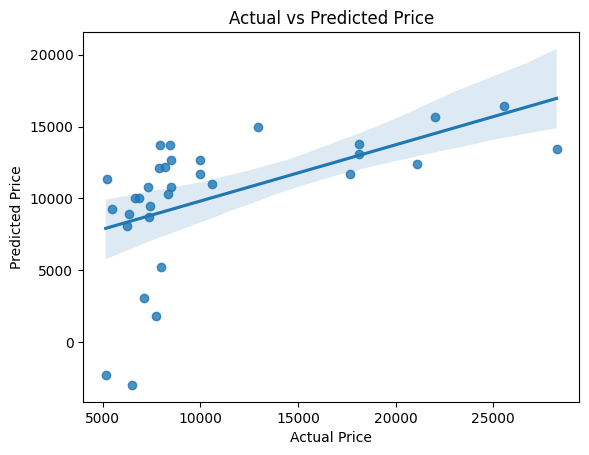

In [32]:
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split

x_train, x_test, y_train, y_test = train_test_split(df1[["highway-mpg"]], df1[["price"]], test_size=0.2, random_state=0)

predict_score = cross_val_predict(lm, x_test, y_test, cv=3)
# print(predict_score)
print("\n")
scores = cross_val_score(lm, x_train, y_train, cv=3)
print(scores)

# plt.scatter(y_test, predict_score)
# plt.xlabel("Actual Price")
# plt.ylabel("Predicted Price")
# plt.title("Actual vs Predicted Price")
# plt.show()

sns.regplot(x=y_test, y=predict_score)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()



Cross-Validation R^2 Scores: [0.51586958 0.74965748 0.57996278]
Average R^2: 0.6151632777747399


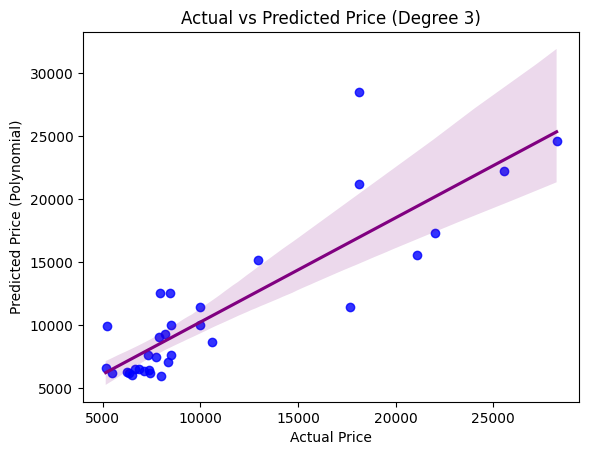

In [33]:
# For non linear regression graph 

# 1. Split the data
x_train, x_test, y_train, y_test = train_test_split(df1[["highway-mpg"]], df1[["price"]], test_size=0.2, random_state=0)

# 2. Create a Polynomial Pipeline (Degree 2)
# We include StandardScaler because Polynomial terms (x^2) can get very large
poly_model = Pipeline([
    ('scale', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('model', LinearRegression())
])

# 3. Get Predictions using Cross Validation on the test set
# (Note: Using cv=3 on the test set is only for visualization of errors)
predict_values = cross_val_predict(poly_model, x_test, y_test, cv=3)

# 4. Get performance scores using Cross Validation on the training set
scores = cross_val_score(poly_model, x_train, y_train, cv=3)
print("Cross-Validation R^2 Scores:", scores)
print("Average R^2:", scores.mean())

# 5. Visualize the results
sns.regplot(x=y_test, y=predict_values, scatter_kws={'color': 'blue'}, line_kws={'color': 'purple'})
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price (Polynomial)")
plt.title("Actual vs Predicted Price (Degree 3)")
plt.show()

In [34]:
# Underfitting and overfitting

rsqtest = []
order = [1, 2, 3, 4, 5]

for n in order:
    pr = PolynomialFeatures(degree=n)
    x_train_pr = pr.fit_transform(df1[["horsepower"]])
    x_test_pr = pr.fit_transform(df1[["horsepower"]])
    pr.fit(x_train_pr, x_test_pr)
    # lr = LinearRegression()
    # lr.fit(x_train_pr, y_train)
    # rsqtest.append(lr.score(x_test_pr, y_test))
    # idk whats wrong here, clean later

print(rsqtest)

[]


<h1>Ridge Regression</h1>

In [35]:
from sklearn.linear_model import Ridge

RidgeModel = Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(yhat[0:5])


[14173.6901053  11185.67502848 15667.69764371 16414.70141291
  6703.65241326]


<h1>Hyperparameter and Grid Search</h1>

In [37]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# parameters = {'alpha': [0.01, 0.1, 1, 10, 100, 1000], 'normalize': [True, False]}

# rr = Ridge()

# Grid1 = GridSearchCV(rr, parameters, cv=4)
parameters = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

rr = Ridge()

Grid1 = GridSearchCV(rr, parameters, cv=4)
Grid1.fit(df1[["horsepower","curb-weight","engine-size", "highway-mpg"]], df1["price"])

Grid1.best_estimator_

scores = Grid1.cv_results_
print(scores)


{'mean_fit_time': array([0.00543243, 0.00530899, 0.00564319, 0.00509018, 0.00603938,
       0.00643086]), 'std_fit_time': array([0.00024879, 0.00049418, 0.00053635, 0.0010076 , 0.00096421,
       0.00024489]), 'mean_score_time': array([0.00379205, 0.00289202, 0.00307554, 0.00316751, 0.00402755,
       0.00355202]), 'std_score_time': array([7.74660451e-05, 3.01110301e-04, 7.44156223e-04, 3.76325677e-04,
       4.44980043e-04, 3.96611595e-04]), 'param_alpha': masked_array(data=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
             mask=[False, False, False, False, False, False],
       fill_value=1e+20), 'params': [{'alpha': 0.01}, {'alpha': 0.1}, {'alpha': 1}, {'alpha': 10}, {'alpha': 100}, {'alpha': 1000}], 'split0_test_score': array([0.75637749, 0.75637747, 0.75637724, 0.75637501, 0.7563539 ,
       0.75620237]), 'split1_test_score': array([0.77147809, 0.7714784 , 0.77148149, 0.77151224, 0.77180752,
       0.77406658]), 'split2_test_score': array([0.64759694, 0.64759753, 0.64760351, 0.64

In [ ]:
# Cross-Validation Score Example
from sklearn.model_selection import cross_val_score

lr1 = LinearRegression()
score = cross_val_score(lr1, df1[["horsepower"]], df1["price"], cv=4)

print(score)
print(score.mean())
print(score.std())

[0.71333688 0.43747571 0.72548362 0.299635  ]
0.5439828036377024
0.18212149565712676


In [39]:
rr1 = Ridge()
parameter2= [{'alpha': [0.001,0.1,1, 10, 100, 1000, 10000, 100000, 100000]}]
grid_search1 = GridSearchCV(rr1, parameter2, cv=4)
print(grid_search1)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000,
                                    100000]}])
